# Random Testing Stuff

In [114]:
from edges_analysis import read_step
from edges_analysis.analysis.levels import ModelData
from edges_cal import xrfi
from edges_cal.modelling import LinLog
import numpy as np
from edges_analysis.analysis.averaging import weighted_mean, bin_gha_unbiased_regular
from edges_analysis.analysis.filters import get_rms_info, RMSInfo
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
%matplotlib inline
%load_ext line_profiler
%load_ext autoreload
%autoreload 2

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [115]:
%config Completer.use_jedi = False

### Fix the ol' RFI

In [116]:
day_avg = read_step("/home/smurray/edges/Steven/edges-cache/level-cache/short_test/xrfi_aux/model_no_rms/small_bins/no-ignore-model-sweep/eight_files.h5")

In [117]:
day_avg.calibration_step.calibration

TypeError: Non-optional key 'neg_flags' not in <HDF5 group "/ancillary" (5 members)>

['/home/smurray/edges/Steven/edges-cache/level-cache/short_test/xrfi_aux/model_no_rms/small_bins/eight_files.h5']


<AxesSubplot:>

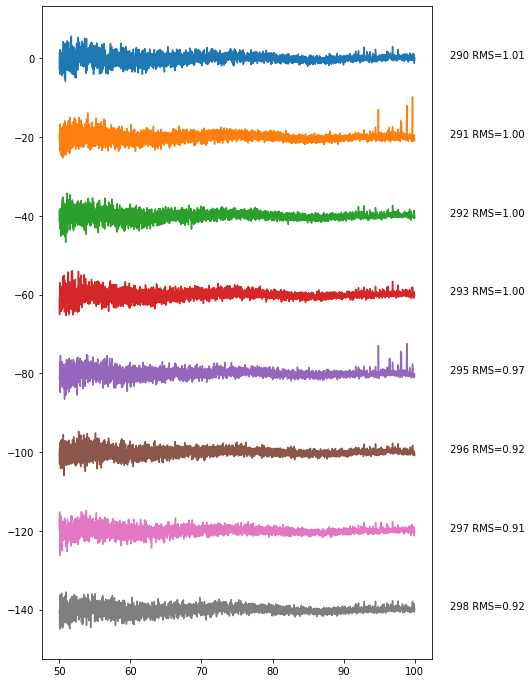

In [5]:
day_avg.combination_step.plot_daily_residuals()

['/home/smurray/edges/Steven/edges-cache/level-cache/short_test/xrfi_aux/model_no_rms/small_bins/eight_files.h5']


<AxesSubplot:>

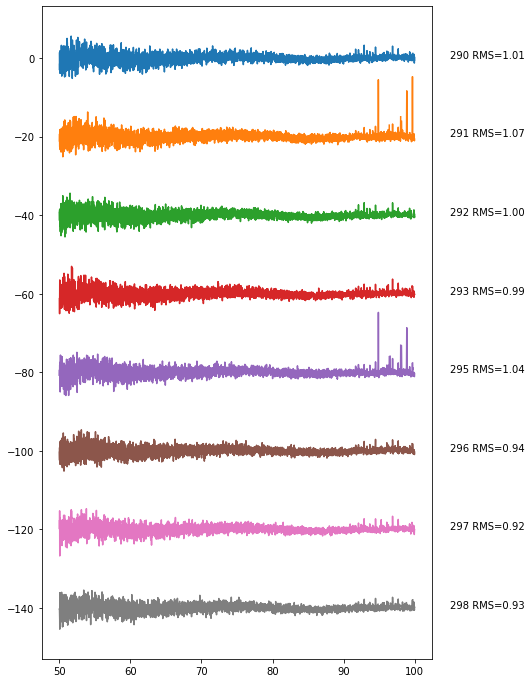

In [5]:
day_avg.combination_step.plot_daily_residuals(weights='old')

['/home/smurray/edges/Steven/edges-cache/level-cache/short_test/xrfi_aux/model_no_rms/small_bins/eight_files.h5']


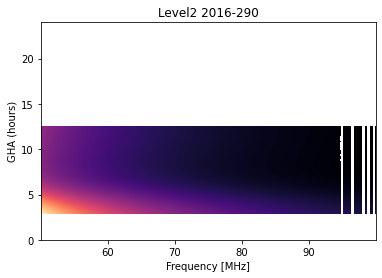

In [5]:
day_avg.combination_step.plot_waterfall(day=290)

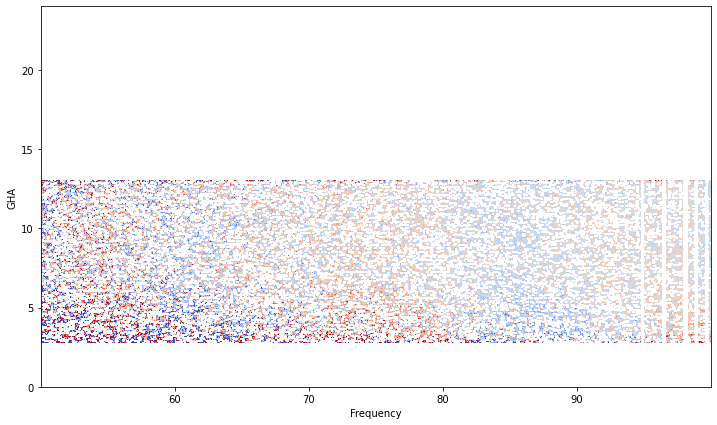

In [27]:
plt.figure(figsize=(12,7))
day_avg.plot_waterfall(quantity='resids', flagged=True, vmin=-4, vmax=4)

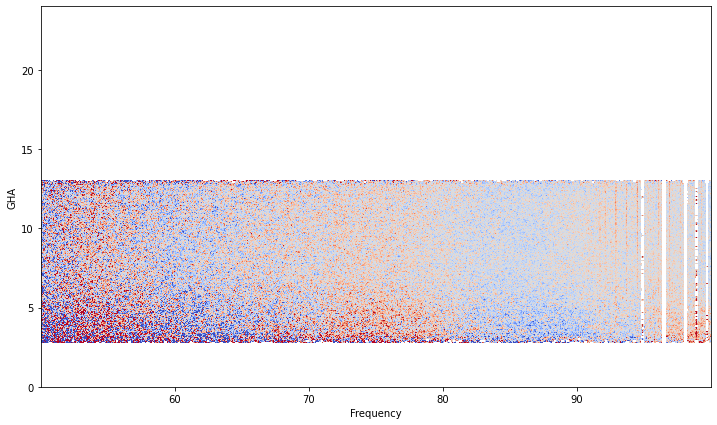

In [28]:
plt.figure(figsize=(12,7))
day_avg.plot_waterfall(quantity='resids', flagged=True, vmin=-4, vmax=4, weights='old')

In [18]:
np.sum(np.isnan(day_avg.resids[160]))

42

In [19]:
q = np.where(day_avg.weights > 0, day_avg.resids, np.nan)

In [20]:
q[160]

array([-5.05182494, -3.93842352, -2.50874564, ..., -0.61497161,
       -0.24991245, -0.24061235])

In [13]:
np.sum(flags_new)

728

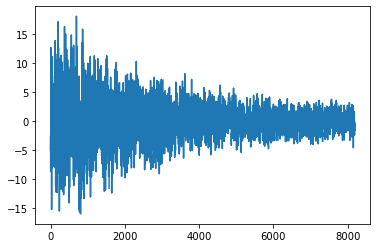

In [21]:
plt.plot(q[160])

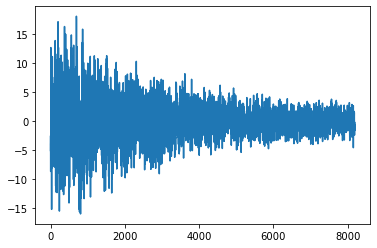

In [12]:
plt.plot(day_avg.resids[160] * ~flags_new)

In [32]:
flags, info = xrfi.xrfi_model_sweep(
    day_avg.spectrum[160], 
    weights=day_avg.ancillary['pre_filter_weights'][160], 
    which_bin='all', watershed=4, max_iter=10, threshold=4
)

/data4/smurray/Projects/radio/EOR/Edges/edges-cal/src/edges_cal/xrfi.py:696: UserWarning: Max iterations reached without finding all xRFI. Consider increasing max_iter.
  "Max iterations reached without finding all xRFI. Consider increasing max_iter."


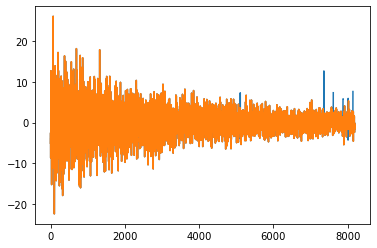

In [33]:
plt.plot(day_avg.resids[160] * day_avg.ancillary['pre_filter_weights'][160].astype(bool))
plt.plot(day_avg.resids[160] * ~flags)

/data4/smurray/Projects/radio/EOR/Edges/edges-analysis/src/edges_analysis/analysis/tools.py:724: RuntimeWarning: Mean of empty slice
  params_out[i] = np.nanmean(these_params, axis=0)


<AxesSubplot:>

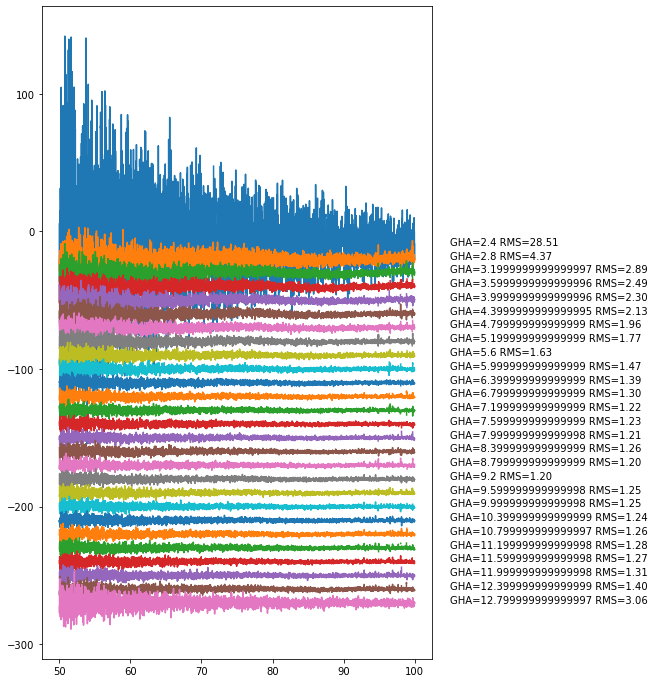

In [37]:
day_avg.plot_resids(gha_min=2, gha_max=14, gha_bin_size=0.4)

/data4/smurray/Projects/radio/EOR/Edges/edges-analysis/src/edges_analysis/analysis/tools.py:724: RuntimeWarning: Mean of empty slice
  params_out[i] = np.nanmean(these_params, axis=0)


<AxesSubplot:>

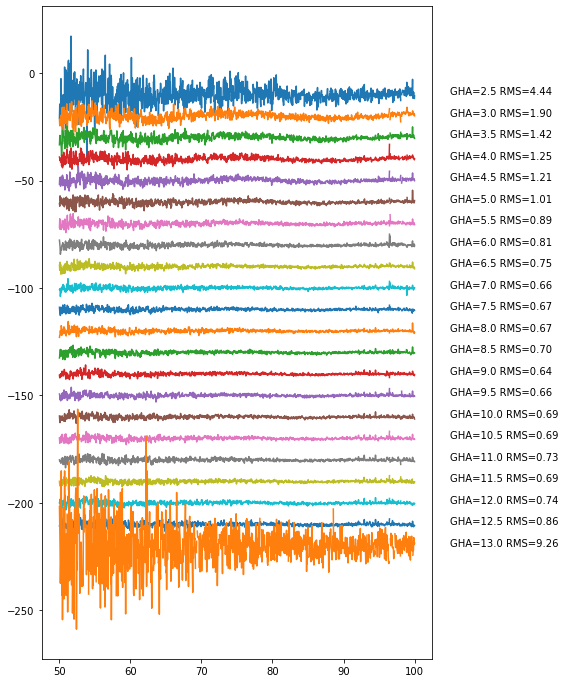

In [39]:
day_avg.plot_resids(gha_min=2, gha_max=14, gha_bin_size=0.5, freq_resolution=0.0488)

In [9]:
full_avg = read_step("/home/smurray/edges/Steven/edges-cache/level-cache/short_test/xrfi_aux/model_no_rms/xrfi_on_resids/no-ignore-model-sweep/half_hour_bins/eight_files.h5")

<AxesSubplot:>

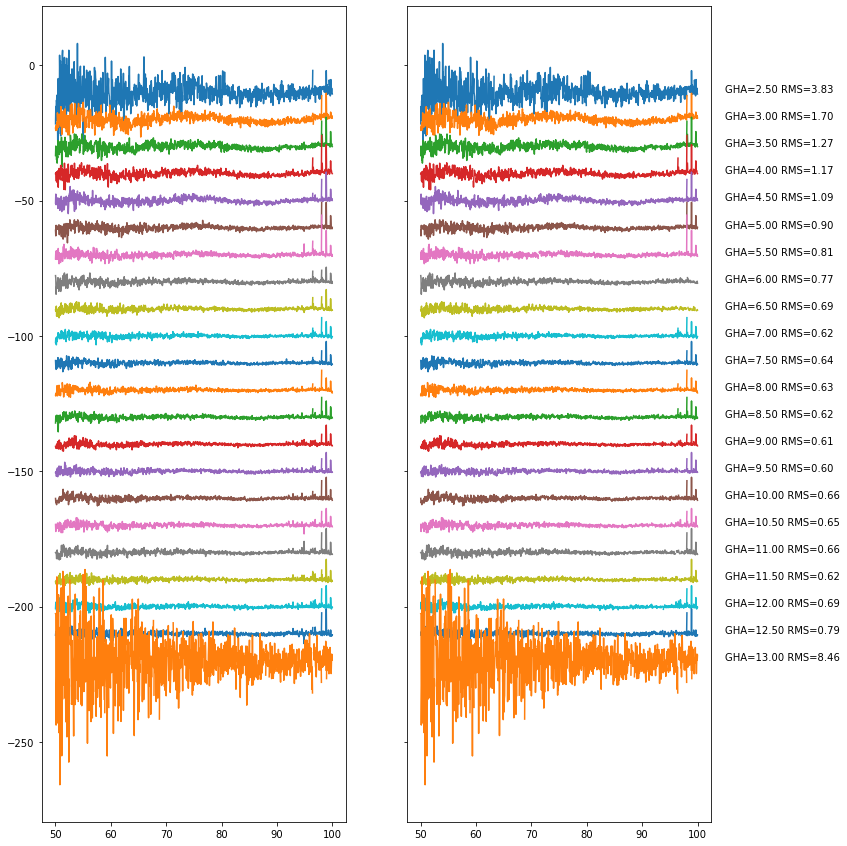

In [10]:
fig, ax = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(12,15))
full_avg.plot_resids(weights='old', ax=ax[0], labels=False)
full_avg.plot_resids(ax=ax[1], labels=True)
#full_avg.plot_resids(ax=ax[2], refit_model=LinLog(n_terms=5, default_x=full_avg.raw_frequencies), labels=False)



In [32]:
full_avg_model = read_step("/home/smurray/edges/Steven/edges-cache/level-cache/short_test/xrfi_aux/model_no_rms/xrfi_model/no-ignore-model/half_hour_bins/eight_files.h5")

<AxesSubplot:>

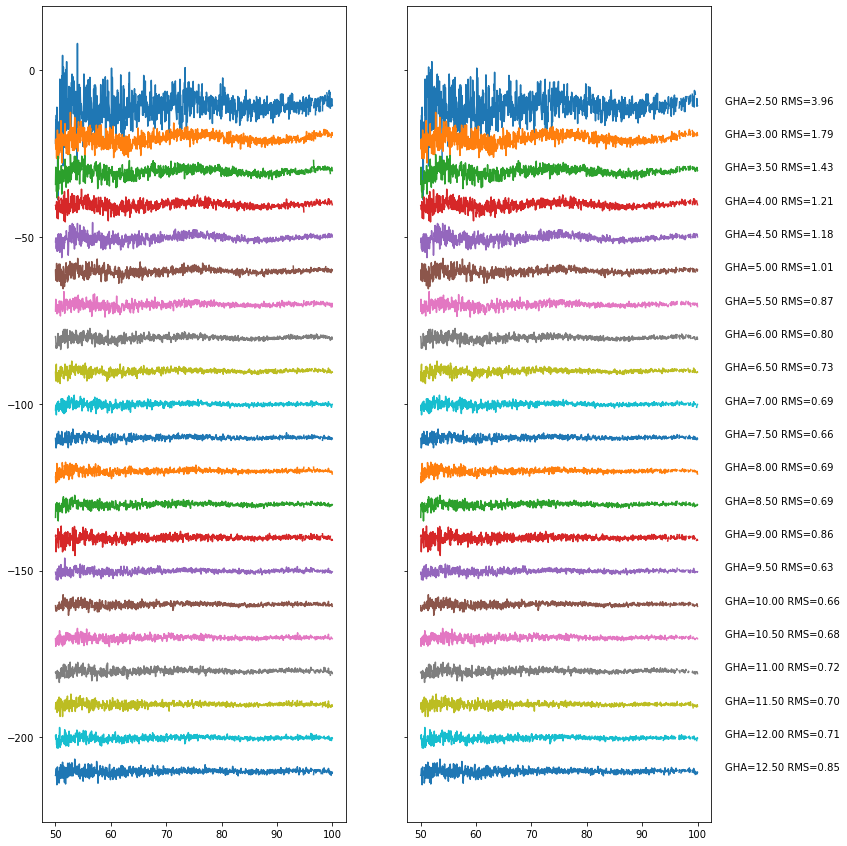

In [33]:
fig, ax = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(12,15))
full_avg_model.plot_resids(weights='old', ax=ax[0], labels=False)
full_avg_model.plot_resids(ax=ax[1], labels=True)
#full_avg.plot_resids(ax=ax[2], refit_model=LinLog(n_terms=5, default_x=full_avg.raw_frequencies), labels=False)



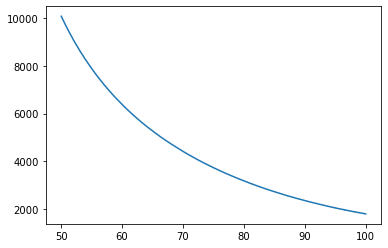

In [18]:
plt.plot(full_avg_model.freq.freq, full_avg_model.spectrum[2])

In [30]:
flags, info = xrfi.xrfi_model(
    full_avg_model.spectrum[6],
    weights=full_avg_model.ancillary['pre_filter_weights'][6],
    freq=full_avg_model.freq.freq,
    model_type='linlog',
    max_iter = 10,
    beta=-2.55,
    increase_order=True,
    threshold=3,
    decrement_threshold=0.5,
    min_threshold=3,
    min_terms=5,
    max_terms=7,
    n_signal=5,
    n_resid=3,
    watershed=1,
    return_models=True
)

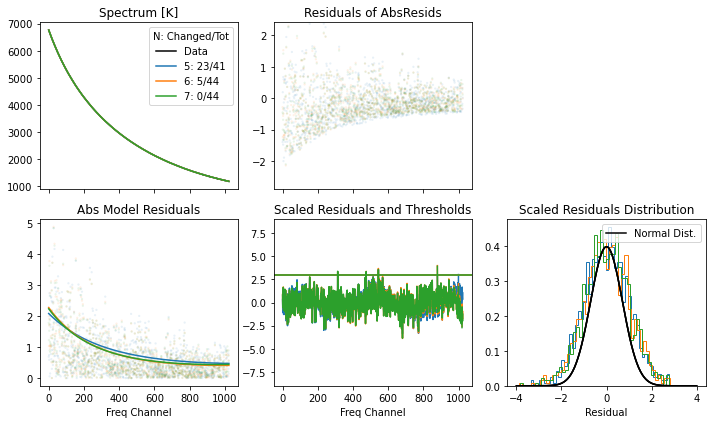

In [31]:
xrfi.visualise_model_info(full_avg_model.spectrum[6], flags, info)

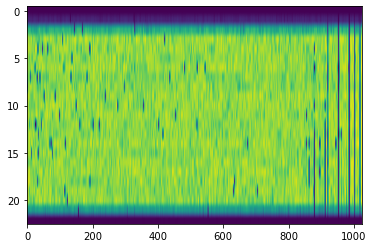

In [10]:
plt.imshow(full_avg.weights, aspect='auto')

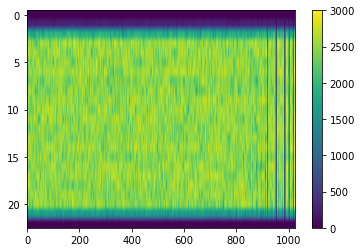

In [12]:
plt.imshow(full_avg.ancillary['pre_filter_weights'], aspect='auto')
plt.colorbar()

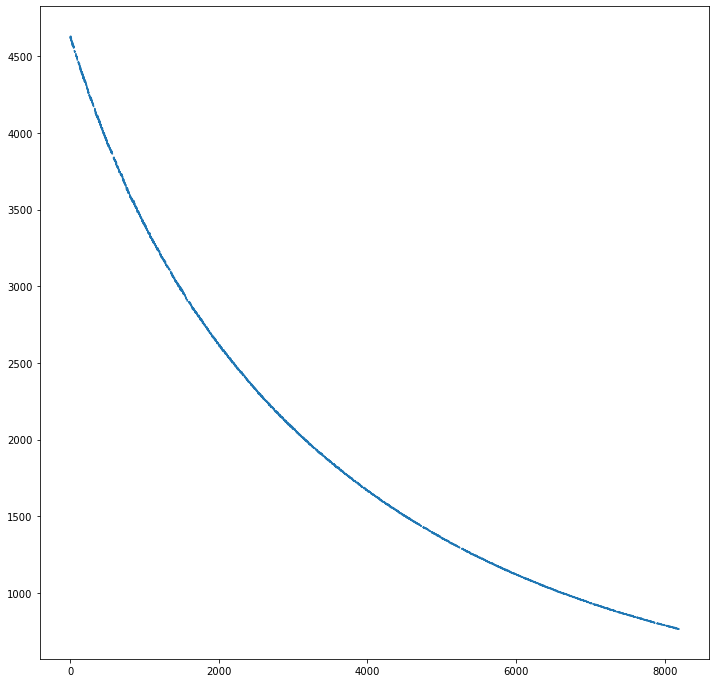

In [18]:
plt.figure(figsize=(12,12))
plt.plot(np.where(flags, np.nan, day_avg.spectrum[160]))

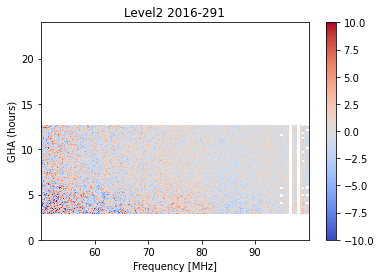

In [13]:
combined_data.plot_waterfall(day=291, quantity='resids', flagged=True, vmin=-10, vmax=10)
plt.colorbar()

In [19]:
np.where(combined_data.ancillary['gha_edges']==8.0)

(array([160]),)

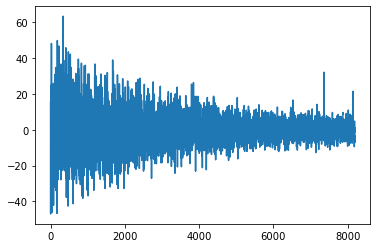

In [21]:
plt.plot(combined_data.resids[1, 161])

In [8]:
combined_data.parent

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (3 members)>: ['spectrum']. Filename=/home/smurray/edges/Steven/edges-cache/level-cache/short_test/xrfi_aux/model_no_rms/2016-290-00.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (3 members)>: ['spectrum']. Filename=/home/smurray/edges/Steven/edges-cache/level-cache/short_test/xrfi_aux/model_no_rms/2016-291-00.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (3 members)>: ['spectrum']. Filename=/home/smurray/edges/Steven/edges-cache/level-cache/short_test/xrfi_aux/model_no_rms/2016-292-00.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges

[ModelData(filename=PosixPath('/home/smurray/edges/Steven/edges-cache/level-cache/short_test/xrfi_aux/model_no_rms/2016-290-00.h5'), require_no_extra=False, lazy=True),
 ModelData(filename=PosixPath('/home/smurray/edges/Steven/edges-cache/level-cache/short_test/xrfi_aux/model_no_rms/2016-291-00.h5'), require_no_extra=False, lazy=True),
 ModelData(filename=PosixPath('/home/smurray/edges/Steven/edges-cache/level-cache/short_test/xrfi_aux/model_no_rms/2016-292-00.h5'), require_no_extra=False, lazy=True),
 ModelData(filename=PosixPath('/home/smurray/edges/Steven/edges-cache/level-cache/short_test/xrfi_aux/model_no_rms/2016-293-00.h5'), require_no_extra=False, lazy=True),
 ModelData(filename=PosixPath('/home/smurray/edges/Steven/edges-cache/level-cache/short_test/xrfi_aux/model_no_rms/2016-295-00.h5'), require_no_extra=False, lazy=True),
 ModelData(filename=PosixPath('/home/smurray/edges/Steven/edges-cache/level-cache/short_test/xrfi_aux/model_no_rms/2016-296-00.h5'), require_no_extra=False

## Full Data Set 

In [46]:
np_data = np.genfromtxt("figure1_plotdata.csv", skip_header=True, delimiter=',')
np_wght = np_data[:, 1]

np_freq = np_data[np_wght > 0, 0]
np_tsky = np_data[np_wght > 0, 2]

In [118]:
full_data = read_step("/home/smurray/edges/Steven/edges-cache/level-cache/nature-paper/no-rms/linlog5-25/bin05-xrfi-model/all-days-with-xrfi/all-files.h5")
full_data_no_beam = read_step("/home/smurray/edges/Steven/edges-cache/level-cache/nature-paper-no-beam/no-rms/linlog5-25/bin05-xrfi-model/all-days-with-xrfi/all-files.h5")

In [119]:
full_data.get_day(290).calibration

AttributeError: 'list' object has no attribute 'calibration'

<AxesSubplot:>

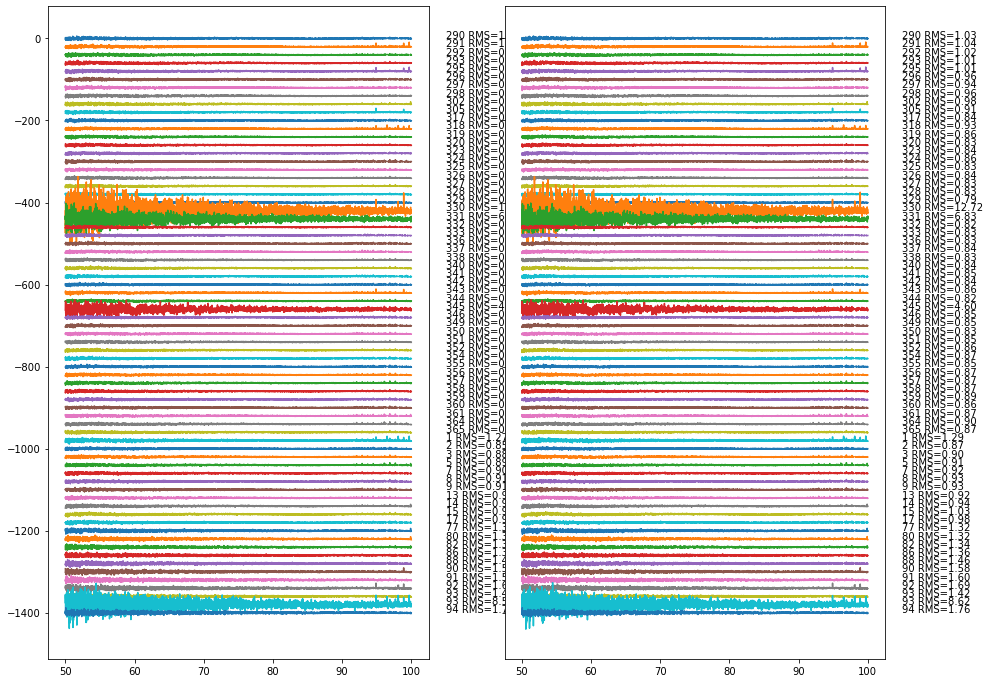

In [57]:
fig, ax = plt.subplots(1, 2, sharey = True, figsize=(15, 12))
full_data.combination_step.plot_daily_residuals(ax=ax[0])
full_data_no_beam.combination_step.plot_daily_residuals(ax=ax[1])


In [53]:
full_data.resids.shape

(48, 1024)

/data4/smurray/Projects/radio/EOR/Edges/edges-analysis/src/edges_analysis/analysis/tools.py:843: RuntimeWarning: Mean of empty slice
  params_out[i] = np.nanmean(these_params, axis=0)
/data4/smurray/Projects/radio/EOR/Edges/edges-analysis/src/edges_analysis/analysis/tools.py:843: RuntimeWarning: Mean of empty slice
  params_out[i] = np.nanmean(these_params, axis=0)


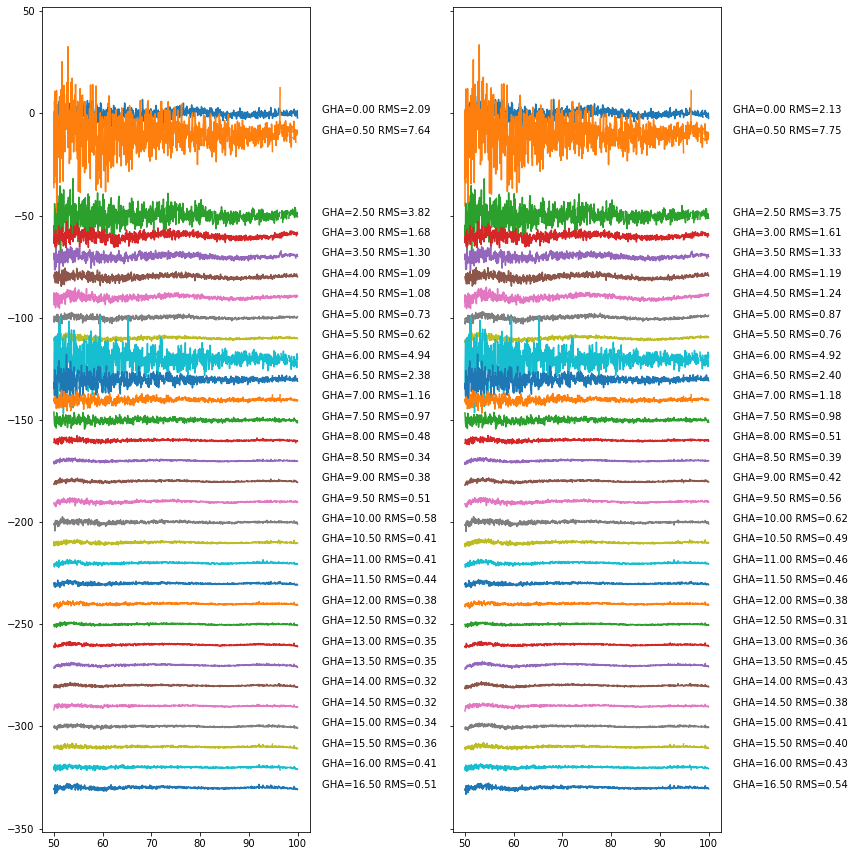

In [58]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(12, 12))
full_data.plot_resids(ax=ax[0], gha_bin_size=0.5, freq_resolution=8)
full_data_no_beam.plot_resids(ax=ax[1], gha_bin_size=0.5, freq_resolution=8)
plt.tight_layout()

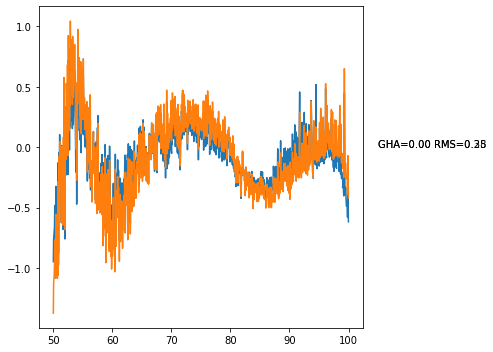

In [65]:
ax = full_data.plot_resids(gha_bin_size=24, freq_resolution=8)
full_data_no_beam.plot_resids(ax=ax, gha_bin_size=24, freq_resolution=8)
plt.tight_layout()

### Run Some Fits

In [107]:
from edges_estimate.eor_models import AbsorptionProfile
from edges_estimate.likelihoods import MultiComponentChi2SigmaLin
from scipy.optimize import minimize
from scipy import stats
from edges_estimate.fitting import semi_linear_fit

In [75]:
def make_absorption(freq, fix=tuple()):
    params={
        'A': {'max':2, 'min': 0, 'fiducial': 0.5}, 
        'nu0': {'min': 60, 'max': 90, 'fiducial': 78}, 
        'tau': {'min': 1, 'max': 20, 'fiducial': 8}, 
        'w': {'min':1, 'max': 25, 'fiducial': 15}
    }
    
    fid = {}
    for p in fix:
        fid[p] = params.pop(p)['fiducial']
        
    return AbsorptionProfile(
        name='absorption',
        fiducial=fid,
        params=params,
        freqs=freq
    )

In [109]:
freq, spec, weights = full_data.fully_averaged_spectrum(freq_resolution=8)

freq = freq[~np.isnan(spec)]
weights = weights[~np.isnan(spec)]
spec = spec[~np.isnan(spec)]

weights = weights[(freq>55) & (freq <95)]
spec = spec[(freq>55) & (freq <95)]
freq = freq[(freq>55) & (freq <95)]

eor = make_absorption(freq, fix=['tau', 'w', 'nu0'])
linlog = LinLog(n_terms=5, default_x=freq)

res = semi_linear_fit(linlog, eor, spec, 1)

In [110]:
res

      fun: 753.4533303638627
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>
      jac: array([0.068394])
  message: b'CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL'
     nfev: 4
      nit: 1
     njev: 2
   status: 0
  success: True
        x: array([0.])

In [103]:
resid0 = get_resid([0], eor, spec, linlog, 1)
resid05 = get_resid([0.5], eor, spec, linlog, 1)


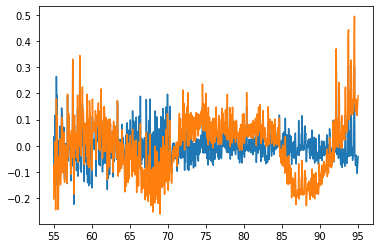

In [106]:
plt.plot(freq, resid0)
plt.plot(freq, resid05)

In [97]:
np.sqrt(np.mean(np.square(resid05))), np.sqrt(np.mean(np.square(resid)))

(0.36928850042860695, 0.34096659050748296)

In [91]:
res

      fun: 7838.03661711134
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>
      jac: array([61.31904229])
  message: b'CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL'
     nfev: 4
      nit: 1
     njev: 2
   status: 0
  success: True
        x: array([0.])

In [10]:
np_resid = LinLog(n_terms=5, default_x=np_freq).fit(ydata=np_tsky).residual

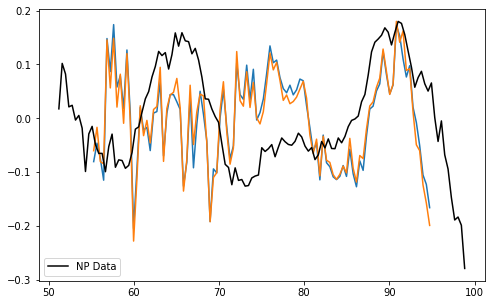

In [17]:
fig, ax = plt.subplots(1,1, figsize=(8,5))

#final_avg_100khz.plot_resids(f_range=(55,95), refit_model=LinLog(n_terms=5, default_x=final_avg_100khz.raw_frequencies), ax=ax, labels=False)
final_avg_400khz.plot_resids(f_range=(55,95), refit_model=LinLog(n_terms=5, default_x=final_avg_400khz.raw_frequencies), ax=ax, labels=False)
final_avg_400_gha_6_18.plot_resids(f_range=(55,95), refit_model=LinLog(n_terms=5, default_x=final_avg_400_gha_6_18.raw_frequencies), ax=ax, labels=False)

plt.plot(np_freq, np_resid, color='k', label='NP Data')
plt.legend()

In [13]:
final_avg_400_gha_6_18.resids

array([], shape=(0, 128), dtype=float64)

In [21]:
np.sum(full_data.ancillary['pre_filter_weights'][-2] > 0), full_data.ancillary['pre_filter_weights'][-2].shape

(1010, (1024,))

In [27]:
flags, info = xrfi.xrfi_model(
    full_data.spectrum[-2],
    weights=full_data.ancillary['pre_filter_weights'][-2],
    freq = full_data.raw_frequencies,
    max_iter=10,
    model_type='linlog',
    beta=-2.55,
    increase_order=True,
    threshold=3,
    decrement_threshold=0,
    min_threshold=3,
    min_terms=5,
    max_terms=7,
    n_signal=5,
    n_resid=3,
    watershed=1
)

In [28]:
info

{'n_flags_changed': [24, 18, 9, 3, 3],
 'total_flags': [38, 44, 53, 56, 53],
 'params': [array([1747.44234448,  -56.1500038 , -662.4165983 , -299.56800925,
         2906.14579077]),
  array([1747.6463433 ,  -56.08571523, -687.76584194, -346.61278691,
         3269.72873334,  843.76736961]),
  array([ 1747.61177815,   -58.08457824,  -686.81627153,  -230.02496249,
          3426.54759377,  -440.38245631, -2617.66305058]),
  array([ 1747.61110147,   -58.0859992 ,  -686.68676157,  -229.47299816,
          3424.3874301 ,  -454.47540481, -2636.21323526]),
  array([ 1747.61134469,   -58.08230927,  -686.71682604,  -229.81112706,
          3424.20550182,  -451.01008736, -2630.18912436])],
 'res_params': [array([  6.56460728, -17.83513236,   7.44260053]),
  array([ 11.6999415 , -30.70992258,  14.5240886 ]),
  array([  6.93826014, -20.34041557,   8.80076608]),
  array([  6.38029637, -19.14859091,   8.16621405]),
  array([  6.35389471, -19.10864004,   8.16049004])],
 'n_iters': 5,
 'model': <edges

In [24]:
np.all(flags)

True

True
True
True
True
True


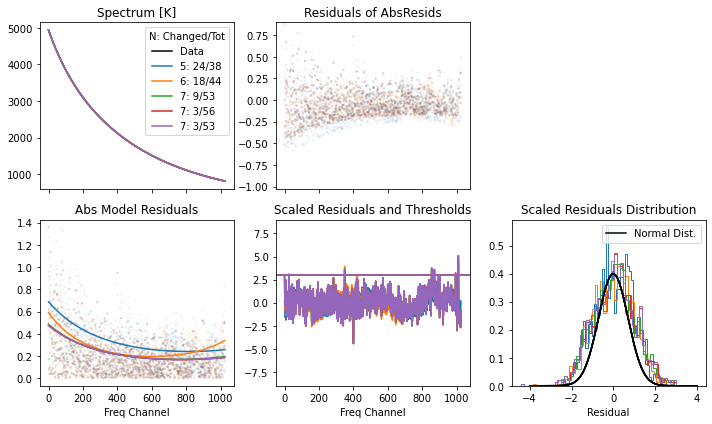

In [29]:
xrfi.visualise_model_info(full_data.spectrum[-2], flags, info)

In [13]:
full_data.combination_step.days

array([290, 291, 292, 293, 295, 296, 297, 298, 302, 305, 317, 318, 319,
       320, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 336,
       337, 338, 340, 341, 342, 343, 344, 345, 346, 349, 350, 351, 352,
       354, 355, 356, 357, 358, 359, 360, 361, 364, 365,   1,   2,   3,
         5,   7,   8,   9,  13,  14,  15,  17,  77,  80,  82,  86,  88,
        90,  91,  92,  93,  93,  94])

In [49]:
full_data.combination_step.days

array([290, 291, 292, 293, 295, 296, 297, 298, 302, 305, 317, 318, 319,
       320, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 336,
       337, 338, 340, 341, 342, 343, 344, 345, 346, 349, 350, 351, 352,
       354, 355, 356, 357, 358, 359, 360, 361, 364, 365,   1,   2,   3,
         5,   7,   8,   9,  13,  14,  15,  17,  18,  19,  77,  80,  82,
        86,  88,  90,  91,  92,  93,  93,  94])

In [38]:
model, params = filtered_data.get_model_parameters(n_terms=5, resolution=0)

In [ ]:
j = np.random.randint(2270)
pp = params[j]

In [29]:
spec = filtered_data.spectra.load("spectrum")

In [34]:
%timeit filtered_data.spectra.load('spectrum')

1.63 µs ± 16.7 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


In [30]:
%%timeit 

spec[10] # - model(parameters=pp)

240 ns ± 0.536 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


In [21]:
filtered_data.spectrum

array([[5552.82953287, 5548.67087879, 5566.5102168 , ...,  957.5842179 ,
         965.38299456,  960.18021762],
       [5489.17814201, 5565.47024474, 5581.70223373, ...,  929.36667555,
         936.99587585,  955.63096018],
       [5610.29347916, 5642.42132459, 5645.41466041, ...,  935.96995875,
         945.80323985,  958.61503121],
       ...,
       [5675.21677158, 5750.57101815, 5774.43792757, ...,  969.78295613,
         965.85775329,  969.94496303],
       [5598.16032289, 5593.41798458, 5512.96814989, ...,  975.72359001,
         974.71183757,  972.5075969 ],
       [5532.14370714, 5484.80922598, 5479.53139277, ...,  982.68916747,
         983.07019894,  978.02429934]])

In [24]:
2270*0.08

181.6

In [41]:
filtered_data.spectrum

array([[5552.82953287, 5548.67087879, 5566.5102168 , ...,  957.5842179 ,
         965.38299456,  960.18021762],
       [5489.17814201, 5565.47024474, 5581.70223373, ...,  929.36667555,
         936.99587585,  955.63096018],
       [5610.29347916, 5642.42132459, 5645.41466041, ...,  935.96995875,
         945.80323985,  958.61503121],
       ...,
       [5675.21677158, 5750.57101815, 5774.43792757, ...,  969.78295613,
         965.85775329,  969.94496303],
       [5598.16032289, 5593.41798458, 5512.96814989, ...,  975.72359001,
         974.71183757,  972.5075969 ],
       [5532.14370714, 5484.80922598, 5479.53139277, ...,  982.68916747,
         983.07019894,  978.02429934]])

In [42]:
%%prun -s cumulative

x = filtered_data.freq.freq

del model.default_basis
model.default_x = x

resids = np.array(
    [filtered_data.spectrum[j] - model(parameters=pp) for j, pp in enumerate(params[:100])]
)

In [5]:
ModelData.promote("/data5/edges/data/Steven/edges-cache/level-cache/short_test/xrfi_aux/2016-290-00.h5", model_resolution=0)

ModelData(filename=None, require_no_extra=False, lazy=True)

In [ ]:
l2 = Level2("/data4/nmahesh/edges/edges-field-levels/level2/a0f0979ed30a87f5d6eb14586c198622/08279cbc7f890b18f2ef3f6cf259a6bd.h5")

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_260_00_00_03.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_261_00_00_06.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_262_00_00_18.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in 

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_298_00_00_27.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_299_00_00_28.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_302_14_53_03.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in 

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_338_00_00_21.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_339_00_00_27.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_340_00_00_28.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in 

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_364_00_00_13.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_365_00_00_01.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_366_00_00_08.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in 

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2017_088_00_00_02.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2017_089_00_00_06.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2017_090_00_00_06.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in 

<AxesSubplot:>

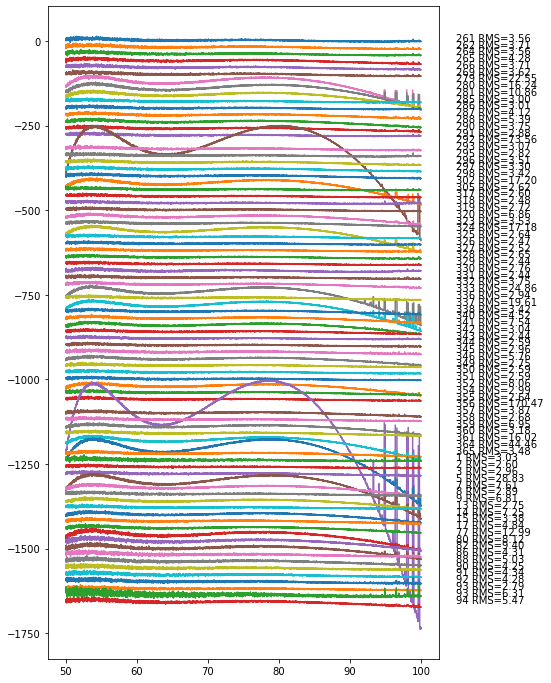

In [4]:
l2.plot_daily_residuals()

In [ ]:
day279 = l2.previous_level[l2.day_index(279, False)]

In [4]:
day262 = l2.previous_level[l2.day_index(262, False)]

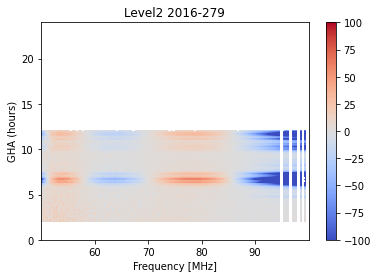

In [5]:
l2.plot_waterfall(day=279, flagged=True, quantity='resids', vmin=-100, vmax=100)
plt.colorbar()

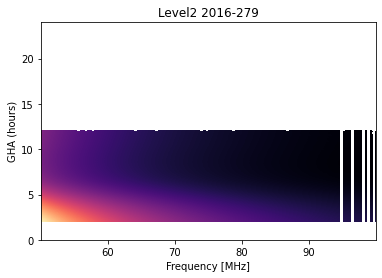

In [6]:
l2.plot_waterfall(day=279, flagged=True, quantity='spectrum')

In [9]:
l2.spectrum.shape

(84, 240, 8192)

In [7]:
np.where(l2.ancillary['gha_edges']>7)

(array([ 71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
         84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,
         97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109,
        110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122,
        123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135,
        136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148,
        149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161,
        162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174,
        175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187,
        188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200,
        201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213,
        214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226,
        227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239,
        240]),)

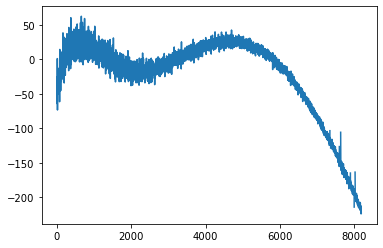

In [6]:
plt.plot(l2.resids[l2.day_index(279), 71])

<AxesSubplot:title={'center':'Day 279. GHA0=14.95'}, xlabel='Frequency [MHz]', ylabel='Hours into Observation'>

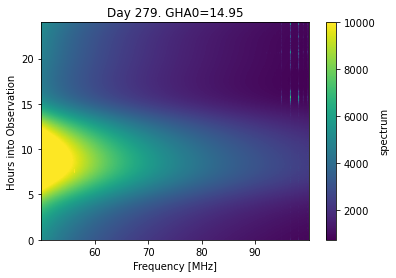

In [7]:
day279.plot_waterfall(vmax=10000)

In [4]:
bad_ghas = np.where((day279.ancillary['gha']>6) & (day279.ancillary['gha']<7.5))[0]

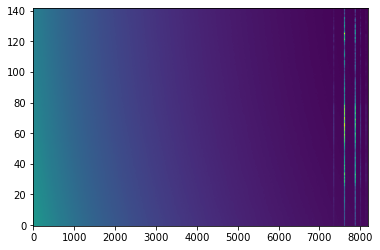

In [5]:
plt.imshow(day279.spectrum[bad_ghas], origin='lower', aspect='auto', vmax=10000)

In [22]:
def get_params_resids(l1, model):
    model, params = l1.get_model_parameters(model, weights=(~flags[0][0]).astype(float), resolution=0, n_terms=5)
    resids = np.array(
        [
            l1.spectrum[j] - model(parameters=pp, x=l1.freq.freq)
            for j, pp in enumerate(params)
        ]
    )
    return model, params, resids

In [23]:
model = 'linlog'
m, p,r = get_params_resids(day279, model)

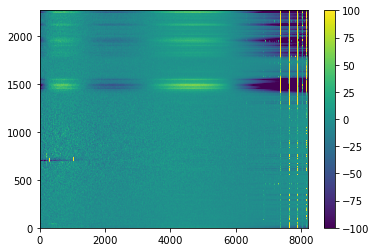

In [24]:
plt.imshow(r, origin='lower', vmin=-100, vmax=100, aspect='auto')
plt.colorbar()

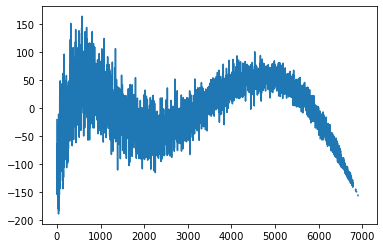

In [43]:
plt.plot(np.where(flags, np.nan, r[1500][:7000]))

In [12]:
day279.ancillary['gha'][2000]

12.135925897634003

In [7]:
0.073 * day279.spectrum.shape[0]

165.856

In [ ]:
flags = {}
info = {}

In [4]:
%%timeit

xrfi.xrfi_model(
    spectrum=day279.spectrum[1500],
    freq=day279.raw_frequencies,
    model_type='linlog',
    beta=-2.5,
    max_iter=15,
    increase_order=True,
    threshold=7,
    decrement_threshold=1.0,
    min_threshold=4,
    min_terms=4,
    max_terms=7,
    n_signal=1,
    n_resid=0,
    inplace=False,
    watershed=4,
    flag_if_broken=False,
    init_flags=day279.raw_frequencies > 90,
)

62.3 ms ± 1.67 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [5]:
%%timeit

xrfi.xrfi_model(
    spectrum=day279.spectrum[1500],
    freq=day279.raw_frequencies,
    model_type='linlog',
    beta=-2.55,
    max_iter=15,
    increase_order=True,
    threshold=7,
    decrement_threshold=1.0,
    min_threshold=4,
    min_terms=4,
    max_terms=7,
    n_signal=1,
    n_resid=0,
    inplace=False,
    watershed=4,
    flag_if_broken=False,
    init_flags=day279.raw_frequencies > 90,
)

63.4 ms ± 18 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [6]:
%%timeit

xrfi.xrfi_model(
    spectrum=day279.spectrum[1500],
    freq=day279.raw_frequencies,
    model_type='linlog',
    beta=-2.5,
    max_iter=15,
    increase_order=True,
    threshold=10,
    decrement_threshold=1.0,
    min_threshold=4,
    min_terms=4,
    max_terms=7,
    n_signal=1,
    n_resid=0,
    inplace=False,
    watershed=4,
    flag_if_broken=False,
    init_flags=day279.raw_frequencies > 90,
)

71.9 ms ± 7.42 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [7]:
init_flags=day279.raw_frequencies > 90

In [8]:
%%timeit

xrfi.xrfi_model(
    spectrum=day279.spectrum[1500],
    freq=day279.raw_frequencies,
    model_type='linlog',
    beta=-2.5,
    max_iter=15,
    increase_order=True,
    threshold=6,
    decrement_threshold=1,
    min_threshold=4,
    min_terms=4,
    max_terms=7,
    n_signal=3,
    n_resid=3,
    inplace=False,
    watershed=4,
    init_flags=init_flags,
)

49.1 ms ± 5.51 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [91]:
flags, info = xrfi.xrfi_model(
    spectrum=day279.spectrum[1500],
    freq=day279.raw_frequencies,
    model_type='linlog',
    beta=-2.5,
    max_iter=15,
    increase_order=True,
    return_models=True,
    threshold=6,
    decrement_threshold=1,
    min_threshold=4,
    min_terms=4,
    max_terms=7,
    n_signal=3,
    n_resid=3,
    inplace=False,
    watershed=5,
    init_flags=init_flags,
)

In [71]:
flags42, info42 = xrfi.xrfi_model(
    spectrum=day279.spectrum[42],
    freq=day279.raw_frequencies,
    model_type='linlog',
    beta=-2.5,
    max_iter=15,
    increase_order=True,
    return_models=True,
    threshold=6,
    decrement_threshold=1,
    min_threshold=4,
    min_terms=4,
    max_terms=7,
    n_signal=3,
    n_resid=3,
    inplace=False,
    watershed=5,
    init_flags=init_flags,
)

In [15]:
flags['fid'], info['fid'] = flg, inf

NameError: name 'flg' is not defined

In [ ]:
%%timeit

flg, inf = xrfi.xrfi_model(
    spectrum=day279.spectrum[1500],
    freq=day279.raw_frequencies,
    model_type='linlog',
    beta=-2.55,
    max_iter=15,
    return_models=True,
    increase_order=True,
    threshold=7,
    decrement_threshold=1.0,
    min_threshold=4,
    min_terms=4,
    max_terms=7,
    n_signal=1,
    n_resid=0,
    inplace=False,
    watershed=4,
    flag_if_broken=False,
    init_flags=day279.raw_frequencies > 90,
)

In [88]:
def visualise_xrfi_model_info(spectrum, flags, info):
    model = info['model']
    res_model = info['res_model']
    
    if not info['params']:
        raise ValueError("can't visualise info if 'return_models' wasn't set")
        
    fig, ax = plt.subplots(2, 3, figsize=(10, 6))
    
    ax[0,0].plot(spectrum, label='Data', color='k')
    
    for i, (pars, res_pars, nchange, tflags, thr) in enumerate(zip(info['params'], info['res_params'], info['n_flags_changed'], info['total_flags'], info['thresholds'])):
        model.update_nterms(len(pars))
        res_model.update_nterms(len(res_pars))
        
        m = model(parameters=pars)
        res = spectrum - m
        
        med = np.median(res)
        mad = xrfi._get_mad(res)
        
        ax[0, 0].plot(m, label=f"{len(pars)}: {nchange}/{tflags}")
        ax[0,0].set_title('Spectrum [K]')
        ax[0,0].axes.xaxis.set_ticklabels([])
        
        ax[1, 0].scatter(np.arange(len(flags)), np.where(flags, np.nan, np.abs(res)), alpha=0.1, edgecolor='none', s=5)
        ax[1, 0].set_xlabel("Freq Channel")
        
        rm = np.sqrt(np.exp(res_model(parameters=res_pars))) / 0.53
        ax[1, 0].plot(rm)

        ax[1, 0].set_title("Abs Model Residuals")
        ax[0, 1].axes.xaxis.set_ticklabels([])
        
        resres = np.abs(res) - rm
        med = np.median(resres)
        mad = xrfi._get_mad(resres)
        
        ax[0, 1].scatter(np.arange(len(flags)),np.where(flags, np.nan, resres), alpha=0.1, edgecolor='none', s=5)
        ax[0, 1].set_ylim(med - 7*mad, med+7*mad)
        ax[0, 1].set_title("Residuals of AbsResids")
        
        ax[1, 1].plot(res/rm,color=f'C{i}')
        ax[1, 1].axhline(thr, color=f'C{i}')
        ax[1, 1].set_ylim(-thr*3, thr*3)
        ax[1, 1].set_title("Scaled Residuals and Thresholds")
        ax[1, 1].set_xlabel("Freq Channel")
        
        ax[1, 2].hist(np.where(flags, np.nan, res/rm), bins=50, histtype='step', density=True)
        
        x = np.linspace(-4, 4, 200)
        ax[1, 2].plot(x, np.exp(-x**2)/np.sqrt(2*np.pi), color='k', label='Normal Dist.' if not i else None)
        ax[1, 2].set_title("Scaled Residuals Distribution")
        
        ax[1, 2].set_xlabel("Residual")
        
        ax[0, 2].axis('off')
        
    ax[0, 0].legend(title='N: Changed/Tot')
    ax[1, 2].legend()
    plt.tight_layout()

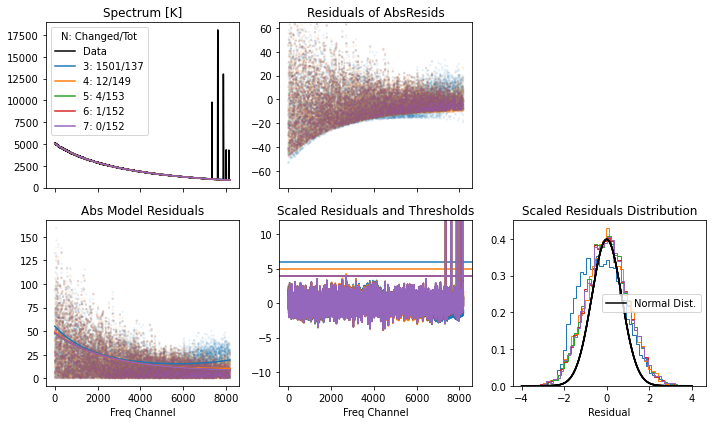

In [92]:
visualise_xrfi_model_info(day279.spectrum[1500], flags, info)

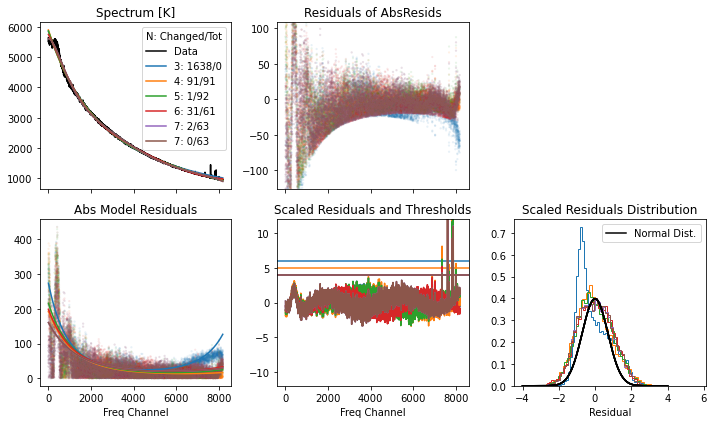

In [89]:
visualise_xrfi_model_info(day279.spectrum[42], flags42, info42)

In [18]:
flags = l2.run_filter('rfi', [day279], nthreads=1, xrfi_pipe={'xrfi_model': dict(
    model_type='linlog',
    beta=-2.55,
    max_iter=15,
    return_models=True,
    increase_order=True,
    threshold=7,
    decrement_threshold=1.0,
    min_threshold=4,
    min_terms=4,
    max_terms=7,
    n_signal=1,
    n_resid=0,
    inplace=False,
    watershed=4,
    flag_if_broken=False,
    init_flags=day279.raw_frequencies > 90,
)})

2016-279-00: Received warning 'max iterations (15) reached, not all RFI might have been caught.' 1/2272 times.


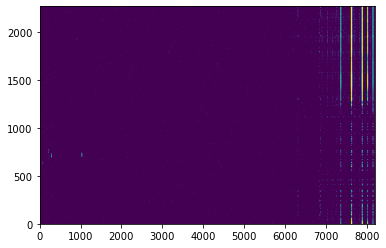

In [19]:
plt.imshow(flags[0][0], origin='lower', aspect='auto')

In [32]:
mdl, params = day279.get_model_parameters(resolution=0, weights=(~flags[0][0]).astype(float), n_terms=5)

In [33]:
res = np.array([day279.spectrum[i] - mdl(parameters=p) for i, p in enumerate(params)])

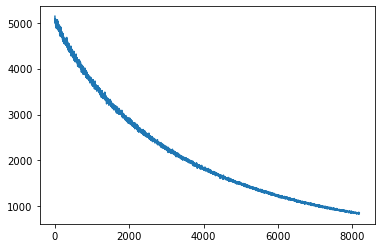

In [34]:
plt.plot(np.where(flags[0][0][1500], np.nan, day279.spectrum[1500]))

In [27]:
linlog = LinLog(n_terms=5, beta=-2.55, default_x = day279.raw_frequencies[~flags[0][0][1500]])

In [24]:
np.sum(flags[0][0][1500])

151

In [28]:
fit = linlog.fit(day279.spectrum[1500][~flags[0][0][1500]])

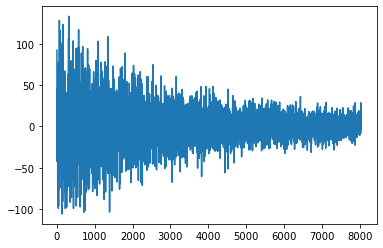

In [29]:
plt.plot(fit.residual)

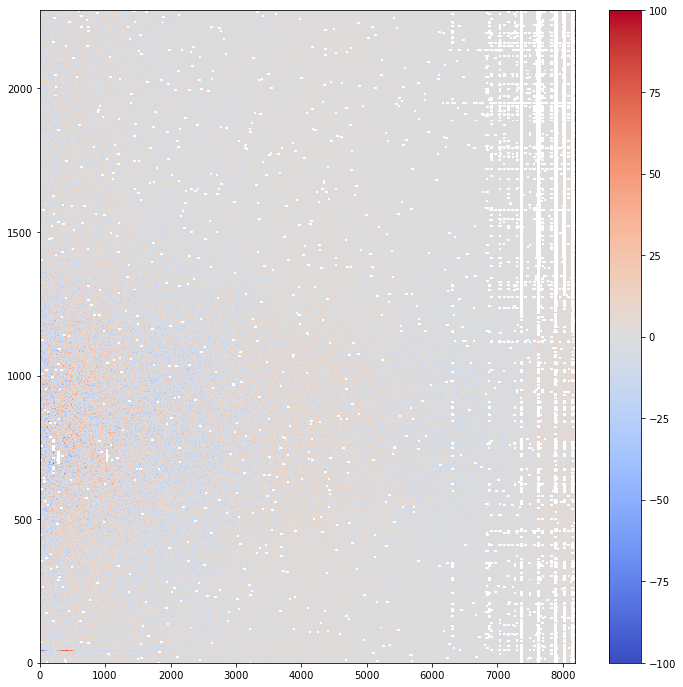

In [74]:
plt.figure(figsize=(12,12))
plt.imshow(np.where(flags[0][0], np.nan, res), origin='lower', aspect='auto', vmin=-100, vmax=100, cmap='coolwarm')
plt.colorbar()

In [70]:
res[42]

array([-222.03787838, -315.59436998, -295.90682571, ...,   18.95521904,
         30.7420785 ,   30.82919159])

In [12]:
day279.ancillary['gha']

array([14.95364516, 14.96450815, 14.97509261, ..., 14.99122205,
       15.00180651, 15.01211242])

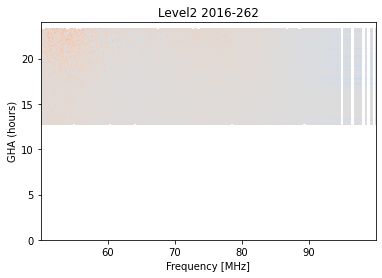

In [10]:
l2.plot_waterfall(day=262, flagged=True, quantity='resids', vmin=-100, vmax=100)

## Performance of `xrfi_model_sweep`

In [40]:
%%timeit -n1 -r1
flg, info = xrfi.xrfi_model_sweep(
    l1.spectrum[0], 
    window_width=100,
    use_median=True,
    n_terms=3,
    threshold=3,
    which_bin='all',
    max_iter=10,
)

3.27 s ± 5.91 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [41]:
%timeit?

In [42]:
%%timeit -n1 -r1
flg, info = xrfi.xrfi_model_sweep(
    l1.spectrum[0], 
    window_width=50,
    use_median=True,
    n_terms=3,
    threshold=3,
    which_bin='all',
    max_iter=10,
)

3.04 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [43]:
%%timeit -n1 -r1
flg, info = xrfi.xrfi_model_sweep(
    l1.spectrum[0], 
    window_width=100,
    use_median=False,
    n_terms=3,
    threshold=3,
    which_bin='all',
    max_iter=10,
)

3.44 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [44]:
%%timeit -n1 -r1
flg, info = xrfi.xrfi_model_sweep(
    l1.spectrum[0], 
    window_width=100,
    use_median=False,
    n_terms=5,
    threshold=3,
    which_bin='all',
    max_iter=10,
)

3.71 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [46]:
%%timeit -n1 -r1
flg, info = xrfi.xrfi_model_sweep(
    l1.spectrum[0], 
    window_width=100,
    use_median=True,
    n_terms=3,
    threshold=4,
    which_bin='all',
    max_iter=10,
)

2.77 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [47]:
%%timeit -n1 -r1
flg, info = xrfi.xrfi_model_sweep(
    l1.spectrum[0], 
    window_width=100,
    use_median=True,
    n_terms=3,
    threshold=3,
    which_bin='last',
    max_iter=10,
)

3.42 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [48]:
%%timeit -n1 -r1
flg, info = xrfi.xrfi_model_sweep(
    l1.spectrum[0], 
    window_width=100,
    use_median=True,
    n_terms=3,
    threshold=3,
    which_bin='all',
    max_iter=1,
)

2.79 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [51]:
%%prun -s cumulative
flg, info = xrfi.xrfi_model_sweep(
    l1.spectrum[0], 
    window_width=100,
    use_median=True,
    n_terms=3,
    threshold=3,
    which_bin='all',
    max_iter=10,
)

In [55]:
%lprun?

In [57]:
%lprun -f 'xrfi_model_sweep' xrfi.xrfi_model_sweep(l1.spectrum[0], use_median=True,which_bin='all',max_iter=10)

/home/smurray/miniconda3/envs/edges/lib/python3.7/site-packages/line_profiler/line_profiler.py:328: UserWarning: Could not extract a code object for the object 'xrfi_model_sweep'
  profile = LineProfiler(*funcs)


## Some Beam Stuff

In [2]:
from scipy.interpolate import RectSphereBivariateSpline
from edges_analysis.analysis.beams import Beam

In [16]:
u = np.linspace(np.pi/2, 0.99*np.pi, 90)
v = np.linspace(0, 1.9*np.pi, 360)
U, V = np.meshgrid(u,v)

In [17]:
r = U.T**2

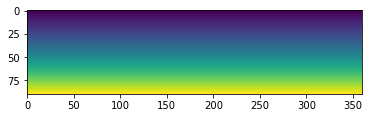

In [18]:
plt.imshow(r)

In [8]:
import healpy as hp

In [30]:
az, el = hp.pix2ang(64, np.arange(hp.nside2npix(64)), lonlat=True)

In [34]:
bm.beam.shape

(31, 91, 360)

In [23]:
el

array([ 87.07581964,  87.07581964,  87.07581964, ..., -87.07581964,
       -87.07581964, -87.07581964])

In [24]:
el

array([ 87.07581964,  87.07581964,  87.07581964, ..., -87.07581964,
       -87.07581964, -87.07581964])

In [25]:
el*np.pi/180 + np.pi/2

array([3.09055608, 3.09055608, 3.09055608, ..., 0.05103658, 0.05103658,
       0.05103658])

In [13]:
el

array([-0.78539816,  0.78539816,  2.35619449, ...,  0.78539816,
        2.35619449,  3.92699082])

In [3]:
bm = Beam.from_feko(Beam.get_beam_path('low'))

In [4]:
az, el = np.meshgrid(bm.azimuth, bm.elevation)

In [31]:
interp = bm.angular_interpolator(0)(az.flatten(), el.flatten())

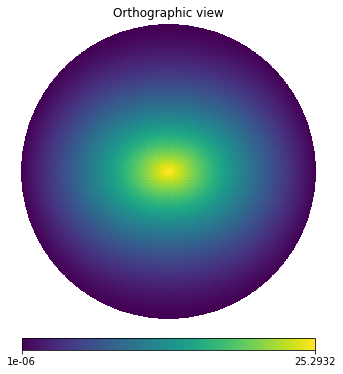

In [32]:
hp.orthview(interp, half_sky=True, rot=(0,-90))

In [27]:
plt.imshow(interp.reshape(az.shape) - bm.beam[0])

ValueError: operands could not be broadcast together with shapes (3072,) (91,360) 

In [7]:
((interp.reshape(az.shape) - bm.beam[0])/bm.beam[0]).min()

-0.0006905369974104905

In [19]:
bm.beam[0,-1]

array([7.18124924, 7.18124924, 7.18124924, 7.18124924, 7.18124924,
       7.18124924, 7.18124924, 7.18124924, 7.18124924, 7.18124924,
       7.18124924, 7.18124924, 7.18124924, 7.18124924, 7.18124924,
       7.18124924, 7.18124924, 7.18124924, 7.18124924, 7.18124924,
       7.18124924, 7.18124924, 7.18124924, 7.18124924, 7.18124924,
       7.18124924, 7.18124924, 7.18124924, 7.18124924, 7.18124924,
       7.18124924, 7.18124924, 7.18124924, 7.18124924, 7.18124924,
       7.18124924, 7.18124924, 7.18124924, 7.18124924, 7.18124924,
       7.18124924, 7.18124924, 7.18124924, 7.18124924, 7.18124924,
       7.18124924, 7.18124924, 7.18124924, 7.18124924, 7.18124924,
       7.18124924, 7.18124924, 7.18124924, 7.18124924, 7.18124924,
       7.18124924, 7.18124924, 7.18124924, 7.18124924, 7.18124924,
       7.18124924, 7.18124924, 7.18124924, 7.18124924, 7.18124924,
       7.18124924, 7.18124924, 7.18124924, 7.18124924, 7.18124924,
       7.18124924, 7.18124924, 7.18124924, 7.18124924, 7.18124

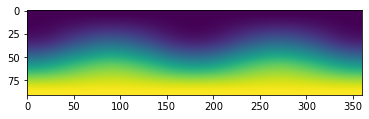

In [8]:
plt.imshow(bm.beam[0])

In [9]:
az = bm.azimuth*np.pi/180

In [22]:
el = (bm.elevation * np.pi/180 + np.pi/2)[:-1]

In [23]:
el

array([1.57079633, 1.58824962, 1.60570291, 1.6231562 , 1.6406095 ,
       1.65806279, 1.67551608, 1.69296937, 1.71042267, 1.72787596,
       1.74532925, 1.76278254, 1.78023584, 1.79768913, 1.81514242,
       1.83259571, 1.85004901, 1.8675023 , 1.88495559, 1.90240888,
       1.91986218, 1.93731547, 1.95476876, 1.97222205, 1.98967535,
       2.00712864, 2.02458193, 2.04203522, 2.05948852, 2.07694181,
       2.0943951 , 2.11184839, 2.12930169, 2.14675498, 2.16420827,
       2.18166156, 2.19911486, 2.21656815, 2.23402144, 2.25147474,
       2.26892803, 2.28638132, 2.30383461, 2.32128791, 2.3387412 ,
       2.35619449, 2.37364778, 2.39110108, 2.40855437, 2.42600766,
       2.44346095, 2.46091425, 2.47836754, 2.49582083, 2.51327412,
       2.53072742, 2.54818071, 2.565634  , 2.58308729, 2.60054059,
       2.61799388, 2.63544717, 2.65290046, 2.67035376, 2.68780705,
       2.70526034, 2.72271363, 2.74016693, 2.75762022, 2.77507351,
       2.7925268 , 2.8099801 , 2.82743339, 2.84488668, 2.86233

In [24]:
U, V = np.meshgrid(el, az)

In [25]:
r = U.T**2

In [31]:
r.shape

(360, 90)

In [21]:
el[:-1]

array([1.57079633, 1.58824962, 1.60570291, 1.6231562 , 1.6406095 ,
       1.65806279, 1.67551608, 1.69296937, 1.71042267, 1.72787596,
       1.74532925, 1.76278254, 1.78023584, 1.79768913, 1.81514242,
       1.83259571, 1.85004901, 1.8675023 , 1.88495559, 1.90240888,
       1.91986218, 1.93731547, 1.95476876, 1.97222205, 1.98967535,
       2.00712864, 2.02458193, 2.04203522, 2.05948852, 2.07694181,
       2.0943951 , 2.11184839, 2.12930169, 2.14675498, 2.16420827,
       2.18166156, 2.19911486, 2.21656815, 2.23402144, 2.25147474,
       2.26892803, 2.28638132, 2.30383461, 2.32128791, 2.3387412 ,
       2.35619449, 2.37364778, 2.39110108, 2.40855437, 2.42600766,
       2.44346095, 2.46091425, 2.47836754, 2.49582083, 2.51327412,
       2.53072742, 2.54818071, 2.565634  , 2.58308729, 2.60054059,
       2.61799388, 2.63544717, 2.65290046, 2.67035376, 2.68780705,
       2.70526034, 2.72271363, 2.74016693, 2.75762022, 2.77507351,
       2.7925268 , 2.8099801 , 2.82743339, 2.84488668, 2.86233

In [15]:
u

array([1.57079633, 1.58809274, 1.60538914, 1.62268555, 1.63998196,
       1.65727837, 1.67457478, 1.69187119, 1.7091676 , 1.72646401,
       1.74376042, 1.76105683, 1.77835323, 1.79564964, 1.81294605,
       1.83024246, 1.84753887, 1.86483528, 1.88213169, 1.8994281 ,
       1.91672451, 1.93402092, 1.95131732, 1.96861373, 1.98591014,
       2.00320655, 2.02050296, 2.03779937, 2.05509578, 2.07239219,
       2.0896886 , 2.10698501, 2.12428141, 2.14157782, 2.15887423,
       2.17617064, 2.19346705, 2.21076346, 2.22805987, 2.24535628,
       2.26265269, 2.2799491 , 2.2972455 , 2.31454191, 2.33183832,
       2.34913473, 2.36643114, 2.38372755, 2.40102396, 2.41832037,
       2.43561678, 2.45291319, 2.47020959, 2.487506  , 2.50480241,
       2.52209882, 2.53939523, 2.55669164, 2.57398805, 2.59128446,
       2.60858087, 2.62587728, 2.64317368, 2.66047009, 2.6777665 ,
       2.69506291, 2.71235932, 2.72965573, 2.74695214, 2.76424855,
       2.78154496, 2.79884137, 2.81613777, 2.83343418, 2.85073

In [30]:
spl = RectSphereBivariateSpline(el, az,r)

In [28]:
spl(np.pi, 0)

array([[9.8696044]])

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_260_00_00_03.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_261_00_00_06.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_262_00_00_18.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in 

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_293_00_00_05.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_294_00_00_36.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_295_00_00_24.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in 

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_339_00_00_27.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_340_00_00_28.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_341_00_00_04.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in 

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2017_005_00_00_05.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2017_006_00_00_15.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2017_007_00_00_35.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in 

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2017_088_00_00_02.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2017_089_00_00_06.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2017_090_00_00_06.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:303: UserWarning: Extra keys found in 

<AxesSubplot:>

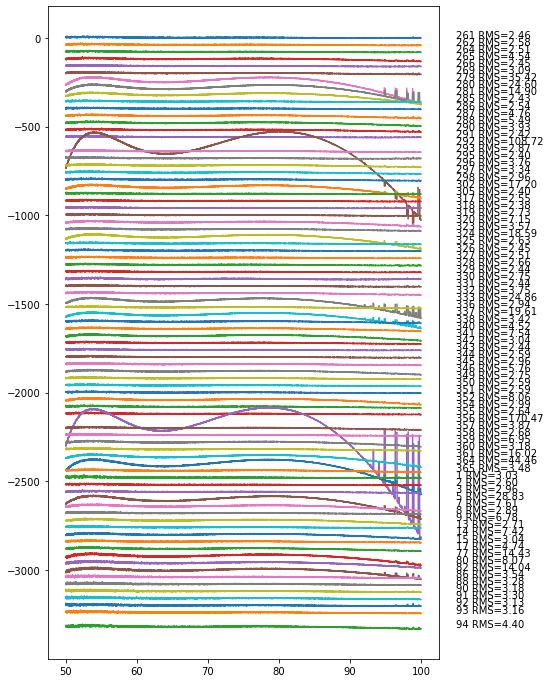

In [39]:
l2.plot_daily_residuals(separation=40, gha_min=6, gha_max=18)

In [2]:
l2_settings = '../../edges-analysis/devel/example_level2_settings.yaml'

In [3]:
with open(l2_settings, 'r') as fl:
    l2settings = yaml.load(fl, Loader=yaml.FullLoader)

In [4]:
l2settings['xrfi_pipe'] = {}

In [5]:
l1 = [Level1(fl) for fl in sorted(Path("/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/").glob("*.h5"))]

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_260_00_00_03.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_261_00_00_06.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_262_00_00_18.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in 

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_326_00_00_08.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_327_00_00_29.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_328_00_00_13.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in 

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2017_090_00_00_06.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2017_091_00_00_00.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2017_092_00_00_29.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in 

In [6]:
l1 = l1[:2]

In [7]:
l2_ = Level2.from_previous_level(l1, **l2settings )

The following 1 files were fully flagged during aux filter:
2016_260_00_00_03.h5


Exception: All input files have been filtered completely.

In [ ]:
l2 = Level2.from_previous_level

In [11]:
l2 = Level2('/data4/nmahesh/edges/edges-field-levels/level2/0668cb6d87c3c36b2a97873726ea3d9e/08279cbc7f890b18f2ef3f6cf259a6bd.h5')

TypeError: Non-optional key 'rms_models' not in <Attributes of HDF5 object at 139632799686328>

In [3]:
l1_ = l2.previous_level[:3]

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_260_00_00_03.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_261_00_00_06.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_rm-bad/2016_262_00_00_18.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in 

In [4]:
rms_info = RMSInfo.from_file("rms_info_tmp.h5")

In [4]:
rms_info = get_rms_info(
    l1_,
    models={
        'poly': {
            'model': 'polynomial',
            'bands': ['full'],
            'params': {
                'n_terms': 5
            },
            'resolution': 0.0488
        }
    }
)

In [6]:
l1_[0].weights.shape

(2258, 8192)

In [4]:
rms_info0 = get_rms_info(
    l1_[:1],
    models={
        'poly': {
            'model': 'polynomial',
            'bands': ['full'],
            'params': {
                'n_terms': 5
            },
            'resolution': 0
        }
    }
)

weights are [[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]]


In [12]:
Level1._structure

{'frequency': <function edges_analysis.analysis.levels.add_structure.<locals>.<lambda>(x)>,
 'spectra': {'weights': <function edges_analysis.analysis.levels.add_structure.<locals>.<lambda>(x)>,
  'spectrum': <function edges_analysis.analysis.levels.add_structure.<locals>.<lambda>(x)>,
  'Q': <function edges_analysis.analysis.levels.add_structure.<locals>.<lambda>(x)>,
  'switch_powers': <function edges_analysis.analysis.levels.add_structure.<locals>.<lambda>(x)>},
 'ancillary': None,
 'meta': {'prev_level_files': None,
  'write_time': None,
  'edges_io_version': None,
  'object_name': None,
  'edges_analysis_version': None,
  'message': <function edges_analysis.analysis.levels.add_structure.<locals>.<lambda>(x)>}}

In [5]:
rms_info.write('rms_info_tmp.h5')

In [7]:
rms_info.bands

{'poly': [(50.0, 100.0)]}

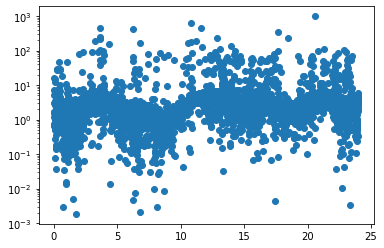

In [8]:
#plt.scatter(rms_info.gha, rms_info.model_eval['poly'][(50.0015259254738,99.9969481490524)])
plt.scatter(rms_info.gha, rms_info.abs_resids['poly'][(50.0,100.0)])
plt.yscale('log')

In [7]:
rms_info.model_params

{'poly': {'model': 'polynomial', 'n_terms': 5, 'resolution': 0.0488}}

In [9]:
l1_[0].ancillary.dtype

dtype([('adcmax', '<f4'), ('adcmin', '<f4'), ('time', 'S17'), ('seconds', '<i8'), ('rack_temp', '<f8'), ('ambient_temp', '<f8'), ('ambient_hum', '<f8'), ('frontend_temp', '<f8'), ('lna_temp', '<f8'), ('temp_set', '<f8'), ('receiver_temp', '<f8'), ('power_percent', '<f8'), ('lst', '<f8'), ('gha', '<f8'), ('sun_az', '<f8'), ('sun_el', '<f8'), ('moon_az', '<f8'), ('moon_el', '<f8')])

In [8]:
l1_[0].ancillary['adcmax']

array([0.28087, 0.30692, 0.2788 , ..., 0.27909, 0.25228, 0.2727 ],
      dtype=float32)

In [5]:
%prun l1_[0].rms_filter(rms_info0)

weights wasnt None, got [[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]]
weights are [[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]]
 

In [10]:
%prun l1_[0].rms_filter(rms_info)

In [5]:
flags = l1_[0].rms_filter(rms_info)

In [9]:
np.sum(flags)/flags.size

0.03675819309123118

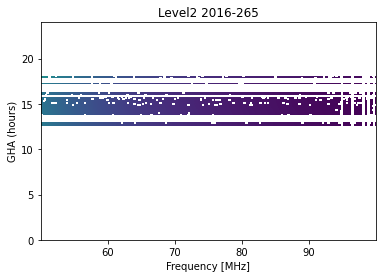

In [12]:
l2.plot_waterfall(day=265, flagged=True)

In [13]:
np.sum(l2.weights[3]>0)/ l2.weights[3].size

0.1755645751953125

In [23]:
# get GHA with maximum rms resid
rmss = np.array([np.sqrt(np.mean(np.square(l2.resids[3][i])[l2.weights[3][i]>0])) for i in range(len(l2.resids[3]))])

In [24]:
rmss[np.isnan(rmss)] = 0

In [25]:
np.argmax(rmss)

30

In [31]:
wmean, _ = weighted_mean(l2.resids[3], weights=l2.weights[3], axis=0)

In [36]:
p,r,w = model_bin_gha(l2.ancillary['model_params'][3], resids=l2.resids[3], weights=l2.weights[3], gha=l2.ancillary['gha_edges'][:-1], bins=[0,24.1])

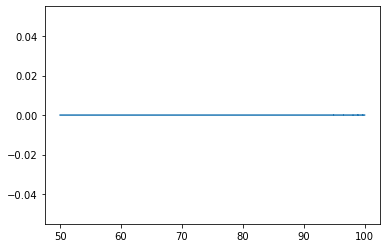

In [41]:
#plt.plot(l2.raw_frequencies, l2.resids[3,30])
plt.plot(l2.raw_frequencies, r[0] - wmean)
#plt.plot(l2.raw_frequencies, wmean)


/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_270_00_00_21.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_273_15_47_58.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_274_00_00_04.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 

<AxesSubplot:>

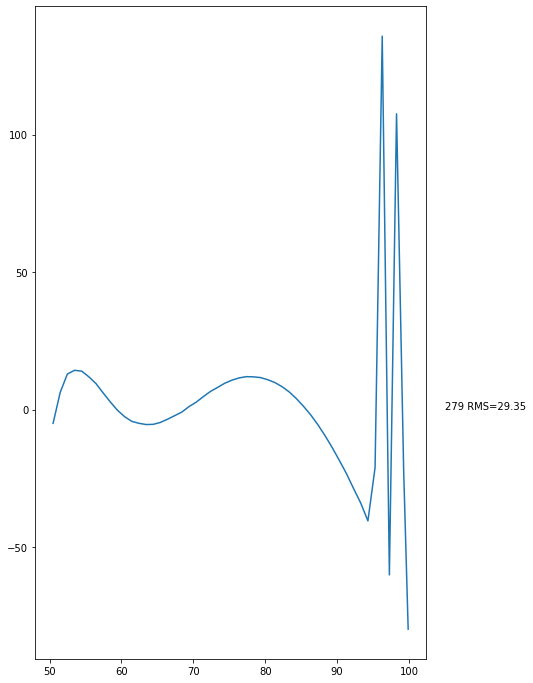

In [3]:
l2.plot_daily_residuals(days=[279], freq_resolution=1.0)

In [3]:
l1 = l2.previous_level[0]

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_270_00_00_21.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_273_15_47_58.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_274_00_00_04.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:297: UserWarning: Extra keys found in <HDF5 

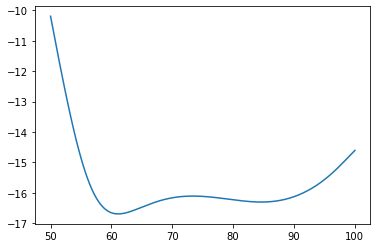

In [8]:
plt.plot(l1.freq.freq, 10*np.log(np.abs(l1._antenna_s11)))

In [14]:
from glob import glob
from edges_analysis.analysis import s11 as s11m

In [20]:
s11_files = sorted(glob('/data5/edges/data/S11_antenna/low_band/20160830_a/s11/*'))
switch_state_dir = '/data5/edges/data/CalibrationObservations/Receiver01/Receiver01_25C_2015_09_02_040_to_200MHz/S11/SwitchingState01/'
switch_state_run_num = 1
n_terms = 15
model = s11m.antenna_s11_remove_delay(
        s11_files,l1.freq.freq,
        switch_state_dir=switch_state_dir,
        delay_0=0.17,
        n_fit=n_terms,
        switch_state_run_num=switch_state_run_num,)[0]
gamma_ant = model(l1.freq.freq)

/home/smurray/miniconda3/envs/edges/lib/python3.7/site-packages/ipykernel_launcher.py:10: RankWarning: Polyfit may be poorly conditioned
  # Remove the CWD from sys.path while we load stuff.
/home/smurray/miniconda3/envs/edges/lib/python3.7/site-packages/ipykernel_launcher.py:10: RankWarning: Polyfit may be poorly conditioned
  # Remove the CWD from sys.path while we load stuff.


In [19]:
l1.meta

{'antenna_correction': False,
 'Level1': {'antenna_correction': False,
  'antenna_s11_n_terms': 15,
  'balun_correction': True,
  'band': 'low',
  'beam_file': '/home/nmahesh/edges-beams/low/beam_factors/feko_Haslam408_ref70.00_22f61e7c4b66d33e811dc6825b04001a.h5',
  'calfile': '/data4/nmahesh/edges/cal_file_Rcv01_2015_09.h5',
  'calobs_path': '/data5/edges/data/Receiver01/Receiver01_2015_09_02_040_to_200MHz/25C',
  'cterms': 7,
  'day': 270,
  'edges_analysis_version': '1.0.0.post0.dev14+g7dbcbd3.dirty',
  'f_high': 100,
  'f_low': 50,
  'freq_max': 200.0,
  'freq_min': 0.0,
  'freq_res': 0.006104,
  'ground_correction': ':',
  'hour': 0,
  'n_file_lines': 13536,
  'n_poly_xrfi': 7,
  'nblk': 40960,
  'nfreq': 32768,
  'object_name': 'Level1',
  'resolution': 24.414,
  's11_files': '/data5/edges/data/S11_antenna/low_band/20160830_a/s11/2016_243_03_53_53_input1.s1p:/data5/edges/data/S11_antenna/low_band/20160830_a/s11/2016_243_03_54_01_input2.s1p:/data5/edges/data/S11_antenna/low_band/

/home/smurray/miniconda3/envs/edges/lib/python3.7/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


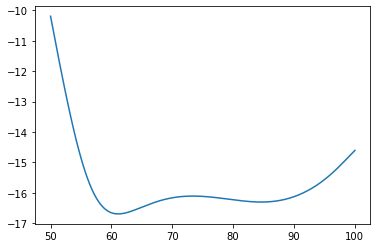

In [21]:
plt.plot(l1.freq.freq, 10*np.log(gamma_ant))

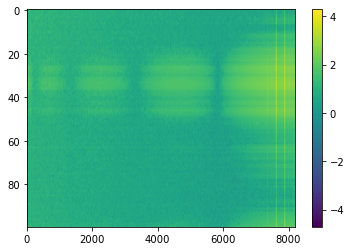

In [3]:
plt.imshow(np.log10(np.abs(l2.resids[0,100:200])), aspect='auto')
plt.colorbar()

In [4]:
l2.model(parameters=l2.ancillary['model_params'][0,180]) + l2.resids[0,180]

array([4645.67479085, 4630.81105076, 4638.56810645, ...,  789.93834569,
        789.97841804,  789.90810494])

In [5]:
l2.spectrum[0,180]

array([4645.67479085, 4630.81105076, 4638.56810645, ...,  789.93834569,
        789.97841804,  789.90810494])

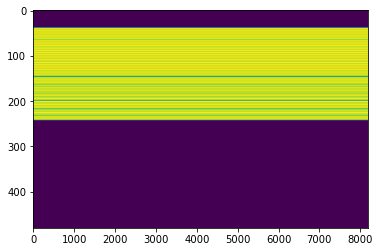

In [6]:
plt.imshow(l2.weights[0], aspect='auto')

/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:294: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_270_00_00_21.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:294: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_273_15_47_58.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:294: UserWarning: Extra keys found in <HDF5 group "/spectra" (5 members)>: ['frequency']. Filename=/data4/nmahesh/edges/edges-field-levels/level1/level1_part/2016_274_00_00_04.h5. 
  warnings.warn(f"{e}. Filename={filename}. ")
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:294: UserWarning: Extra keys found in <HDF5 

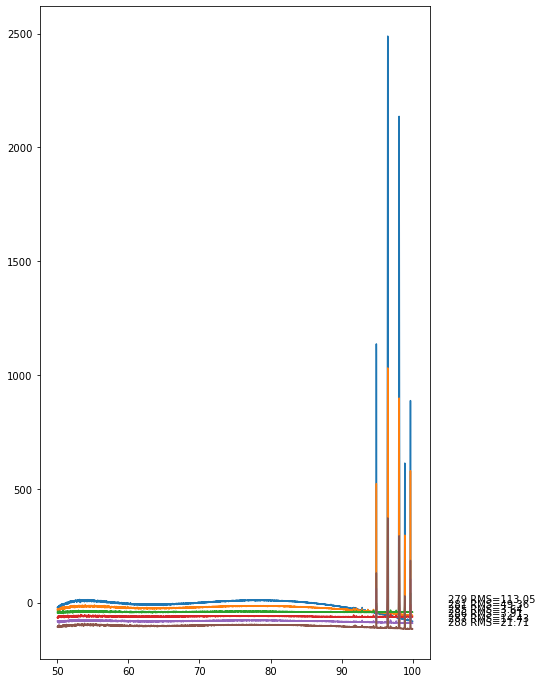

In [7]:
l2.plot_daily_residuals();

In [2]:
l3 = Level3('/data4/nmahesh/edges/edges-field-levels/level3/6dec36b768fdbe5b6c295d463900e7e1/08279cbc7f890b18f2ef3f6cf259a6bd.h5')

In [4]:
l4 = Level4('/home/smurray/edges/Steven/edges-cache/level-cache/level4/516c1d45215790ad13e67f91a623b6fd/08279cbc7f890b18f2ef3f6cf259a6bd.h5')

In [3]:
l3.spectrum.shape

(240, 8192)

In [5]:
l4.spectrum.shape

KeyboardInterrupt: 

In [10]:
l4.previous_level.previous_level.__class__.__name__

'Level2'

## Read Test Level FIles

In [5]:
settings

{'band': 'low',
 'f_low': 50,
 'f_high': 100,
 'calfile': 'cal_file_Rcv01_2015_09.h5',
 's11_path': 's11',
 'switch_state_dir': 'SwitchingState01',
 'balun_correction': True,
 'antenna_correction': False,
 'ground_correction': ':',
 'beam_file': 'feko_Haslam408_ref70.00_22f61e7c4b66d33e811dc6825b04001a.h5',
 'thermlog_file': 'thermlog_low.txt',
 'weather_file': 'weather_upto_20171125.txt'}

In [14]:
l1.filename.absolute()

PosixPath('/data4/smurray/Projects/radio/EOR/Edges/projects_with_nive/edges-bowman2018-pipeline/../../level1/292.h5')

In [15]:

integration_test_data = Path('../../edges-analysis-test-data')

settings = {
    "band": "low",
    "f_low": 50,
    "f_high": 100,
    "calfile": str(integration_test_data / "cal_file_Rcv01_2015_09.h5"),
    "s11_path": str(integration_test_data / "s11"),
    "switch_state_dir": str(integration_test_data / "SwitchingState01"),
    "balun_correction": True,
    "antenna_correction": False,
    "ground_correction": ":",
    "beam_file": str(integration_test_data / "feko_Haslam408_ref70.00.h5"),
    "thermlog_file": str(integration_test_data / "thermlog_low.txt"),
    "weather_file": str(integration_test_data / "weather.txt"),
}


l1 = Level1.from_acq(
    integration_test_data / "2016_292_00_small.acq",
    out_file="/data4/smurray/Projects/radio/EOR/Edges/292.h5",
    **settings
)
l1.write()

l2 = Level1.from_acq(
    integration_test_data / "2016_295_00_small.acq",
    out_file="/data4/smurray/Projects/radio/EOR/Edges/295.h5",
    **settings
)
l2.write()


Reading 2016_292_00_small.acq:  96%|█████████▌| 96/100 [00:00<00:00, 755.28lines/s]
/data4/smurray/Projects/radio/EOR/Edges/edges-analysis/src/edges_analysis/analysis/levels.py:995: UserWarning: You should use the switch state that is inherently in the calibration object.
  "You should use the switch state that is inherently in the calibration object."
/data4/smurray/Projects/radio/EOR/Edges/edges-analysis/src/edges_analysis/analysis/levels.py:879: RankWarning: Polyfit may be poorly conditioned
  switch_state_run_num=switch_state_run_num,
/data4/smurray/Projects/radio/EOR/Edges/edges-analysis/src/edges_analysis/analysis/levels.py:879: RankWarning: Polyfit may be poorly conditioned
  switch_state_run_num=switch_state_run_num,
/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:97: UserWarning: Data had extra key! Extras:  ['year', 'day', 'hour', 'band', 'xrfi_pipe', 'resolution', 'temperature', 'nblk', 'nfreq', 'freq_min', 'freq_max', 'freq_res', 'n_file_lines', 'thermlo

frequency
spectrum
switch_powers
weights
Q
adcmax
adcmin
times
seconds
rack_temp
ambient_temp
ambient_hum
frontend_temp
lna_temp
temp_set
receiver_temp
power_percent
lst
gha
sun_az
sun_el
moon_az
moon_el
year
day
hour
band
xrfi_pipe
resolution
temperature
nblk
nfreq
freq_min
freq_max
freq_res
n_file_lines
thermlog_file
weather_file
s11_files
antenna_s11_n_terms
antenna_correction
balun_correction
ground_correction
beam_file
f_low
f_high
n_poly_xrfi
wterms
cterms
calfile
calobs_path
switch_state_dir
switch_state_run_num
write_time
edges_io_version
object_name
edges_analysis_version
message


Reading 2016_295_00_small.acq:  96%|█████████▌| 96/100 [00:00<00:00, 736.55lines/s]
/data4/smurray/Projects/radio/EOR/Edges/edges-analysis/src/edges_analysis/analysis/levels.py:995: UserWarning: You should use the switch state that is inherently in the calibration object.
  "You should use the switch state that is inherently in the calibration object."
/data4/smurray/Projects/radio/EOR/Edges/edges-analysis/src/edges_analysis/analysis/levels.py:879: RankWarning: Polyfit may be poorly conditioned
  switch_state_run_num=switch_state_run_num,
/data4/smurray/Projects/radio/EOR/Edges/edges-analysis/src/edges_analysis/analysis/levels.py:879: RankWarning: Polyfit may be poorly conditioned
  switch_state_run_num=switch_state_run_num,


frequency
spectrum
switch_powers
weights
Q
adcmax
adcmin
times
seconds
rack_temp
ambient_temp
ambient_hum
frontend_temp
lna_temp
temp_set
receiver_temp
power_percent
lst
gha
sun_az
sun_el
moon_az
moon_el
year
day
hour
band
xrfi_pipe
resolution
temperature
nblk
nfreq
freq_min
freq_max
freq_res
n_file_lines
thermlog_file
weather_file
s11_files
antenna_s11_n_terms
antenna_correction
balun_correction
ground_correction
beam_file
f_low
f_high
n_poly_xrfi
wterms
cterms
calfile
calobs_path
switch_state_dir
switch_state_run_num
write_time
edges_io_version
object_name
edges_analysis_version
message


/data4/smurray/Projects/radio/EOR/Edges/edges-io/src/edges_io/h5.py:97: UserWarning: Data had extra key! Extras:  ['year', 'day', 'hour', 'band', 'xrfi_pipe', 'resolution', 'temperature', 'nblk', 'nfreq', 'freq_min', 'freq_max', 'freq_res', 'n_file_lines', 'thermlog_file', 'weather_file', 's11_files', 'antenna_s11_n_terms', 'antenna_correction', 'balun_correction', 'ground_correction', 'beam_file', 'f_low', 'f_high', 'n_poly_xrfi', 'wterms', 'cterms', 'calfile', 'calobs_path', 'switch_state_dir', 'switch_state_run_num']
  f"Data had extra key! Extras: {str(e).split(':')[-1]}"


In [19]:
rms_info = get_rms_info([l1], 
    models={'linlog':{'resolution': 0, 'params': {'n_terms': 3}, 'bands': ['low', 'full', 'high'], 'model': 'linlog'}}
)

/data4/smurray/Projects/radio/EOR/Edges/edges-analysis/src/edges_analysis/analysis/filters.py:221: RankWarning: Polyfit may be poorly conditioned
  this.update(get_rms_model_over_time(this["rms"], gha, n_poly, n_sigma, n_terms, n_std))
/data4/smurray/Projects/radio/EOR/Edges/edges-analysis/src/edges_analysis/analysis/filters.py:221: RankWarning: Polyfit may be poorly conditioned
  this.update(get_rms_model_over_time(this["rms"], gha, n_poly, n_sigma, n_terms, n_std))
/data4/smurray/Projects/radio/EOR/Edges/edges-analysis/src/edges_analysis/analysis/filters.py:221: RankWarning: Polyfit may be poorly conditioned
  this.update(get_rms_model_over_time(this["rms"], gha, n_poly, n_sigma, n_terms, n_std))


In [21]:
rms_info.gha

array([15.80953273, 15.82011719, 15.83070164, 15.8412861 , 15.85187056,
       15.86245501, 15.87303947, 15.88362392, 15.89420838, 15.90479283,
       15.91537729, 15.92596174, 15.9365462 , 15.94713066, 15.95771511,
       15.96802103])

In [22]:
l2.ancillary['gha']

array([16.0105641 , 16.02114856, 16.03173301, 16.04203893, 16.05290192,
       16.06348638, 16.0737923 , 16.08465529, 16.09496121, 16.10554567,
       16.11613012, 16.12671458, 16.13729904, 16.14816203, 16.15874649,
       16.16933094])

In [3]:
!ls ../../

2015_calibration.tmp.faster-model.h5
2015_calibration.tmp.master.h5
All_cal-params_50.0_189.996337890625_11-12_25C_s11alan.txt
ambient_05002925ba958af9da49fb1e0ca206fc.h5
ambient_3674c3a728b376b74a3dabfc8e504fd2.h5
ambient_61bedf9644acb5ead4dc8a5fdfc8a5bf.h5
ambient_7fb62450b5b29e507a2519c91be561ff.h5
ambient_b225c2075c147f3f57b48bc4048e0ee8.h5
ambient_ece6a33884344d79ed7999c90110b217.h5
ambient_s11.pdf
bayesian-calibration
data_6to18hr
derpymcderpface_Ambient_01_2015_300_00_00_00_lab.csv.csv
derpymcderpface_HotLoad_01_2015_300_09_00_00_lab.csv.csv
derpymcderpface_LongCableOpen_01_2015_300_09_00_00_lab.csv.csv
derpymcderpface_LongCableShorted_01_2015_300_09_00_00_lab.csv.csv
dual_band_fits
edges-analysis
edges-analysis-test-data
edges-beam-stuff.ipynb
edges-cal
edges-cal-tmp
edges_estimate
edges_fits
edges-io
filters_and_performance.ipynb
hot_load_0479258cdeb69d94a95125ec03663709.h5
hot_load_737257d89e55a202e1de28c381e79e9c.h5
hot_load_77843635780ca19d549494632ed54068.h5
hot_load_a56f3